# FIFA 24 Player Stats Analysis

Exploratory analysis and hypothesis testing on the EA Sports FC 24 male players dataset. The goal is to understand what drives a player's market value (`value_eur`) and how player attributes relate to position, age, reputation and preferred foot.

## Reading and filtering the dataset (keep only FIFA version 24)

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_raw = pd.read_csv('male_players.csv', low_memory=False)
print('Full dataset:', df_raw.shape)
print('Versions:', sorted(df_raw['fifa_version'].dropna().unique()))

df = df_raw[df_raw['fifa_version'] == 24.0].copy().reset_index(drop=True)
print('FIFA 24:', df.shape)

Full dataset: (180021, 109)
Versions: [np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0)]
FIFA 24: (18350, 109)


In [3]:
df

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,...,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,19+3
4,165153,/player/165153/karim-benzema/240002,24.0,2.0,2023-09-22,K. Benzema,Karim Benzema,"CF, ST",90,90,...,64+3,64+3,64+3,64+3,60+3,55+3,55+3,55+3,60+3,18+3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18345,273759,/player/273759/saphaba-telem/240002,24.0,2.0,2023-09-22,S. Telem,Saphaba Singh Telem,CB,47,57,...,39+2,39+2,39+2,41+2,43+2,47+2,47+2,47+2,43+2,13+2
18346,269013,/player/269013/liangkuan-jin/240002,24.0,2.0,2023-09-22,Jin Liangkuan,金良宽,CB,47,55,...,43+2,43+2,43+2,44+2,46+2,47+2,47+2,47+2,46+2,13+2
18347,272748,/player/272748/mijit-mewlan/240002,24.0,2.0,2023-09-22,M. Mewlan,买乌郎·米吉提,ST,47,55,...,31+2,31+2,31+2,35+2,33+2,27+2,27+2,27+2,33+2,13+2
18348,269534,/player/269534/jie-yin/240002,24.0,2.0,2023-09-22,Yin Jie,尹杰,CM,47,54,...,45+2,45+2,45+2,45+2,45+2,44+2,44+2,44+2,45+2,14+2


### Selecting and describing the columns relevant for the analysis

In [4]:
cols = [
    'short_name', 'player_positions',
    'value_eur',
    'overall', 'potential',
    'age',
    'international_reputation',
    'preferred_foot', 'weak_foot', 'skill_moves',
    'height_cm', 'weight_kg',
    'pace', 'shooting', 'passing',
    'dribbling', 'defending', 'physic',
]
df = df[cols].copy()
print('Columns left:', df.shape[1])
df.head(3)

Columns left: 18


,short_name,player_positions,value_eur,overall,potential,age,international_reputation,preferred_foot,weak_foot,skill_moves,height_cm,weight_kg,pace,shooting,passing,dribbling,defending,physic
0,K. Mbappé,"ST, LW",181500000.0,91,94,24,5,Right,4,5,182,75,97.0,90.0,80.0,92.0,36.0,78.0
1,E. Haaland,ST,185000000.0,91,94,22,5,Left,3,3,195,94,89.0,93.0,66.0,80.0,45.0,88.0
2,K. De Bruyne,"CM, CAM",103000000.0,91,91,32,5,Right,5,4,181,75,72.0,88.0,94.0,87.0,65.0,78.0


In [5]:
cat_cols = df.drop(columns=["short_name"]).select_dtypes("object").columns
df[cat_cols].describe()

/tmp/ipykernel_526/1528855547.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.drop(columns=["short_name"]).select_dtypes("object").columns


,player_positions,preferred_foot
count,18350,18350
unique,711,2
top,CB,Right
freq,2385,13877


In [6]:
num_cols = df.select_dtypes("number").columns
df[num_cols].describe()

,value_eur,overall,potential,age,international_reputation,weak_foot,skill_moves,height_cm,weight_kg,pace,shooting,passing,dribbling,defending,physic
count,1.825000e+04,18350.000000,18350.000000,18350.000000,18350.000000,18350.000000,18350.000000,18350.000000,18350.000000,16305.000000,16305.000000,16305.000000,16305.000000,16305.000000,16305.000000
mean,2.837585e+06,65.817057,71.088065,25.267139,1.088065,2.941417,2.386594,181.698747,75.210354,68.371788,52.582091,57.489850,62.839497,52.093468,64.901564
std,7.562794e+06,6.817917,6.220982,4.757756,0.364488,0.680378,0.775725,6.869995,6.985703,10.766770,13.900844,9.898202,9.448958,16.026187,9.922964
min,1.000000e+04,47.000000,48.000000,16.000000,1.000000,1.000000,1.000000,156.000000,49.000000,27.000000,19.000000,25.000000,28.000000,15.000000,32.000000
25%,4.750000e+05,62.000000,67.000000,21.000000,1.000000,3.000000,2.000000,177.000000,70.000000,62.000000,42.000000,51.000000,57.000000,38.000000,58.000000
50%,1.000000e+06,66.000000,71.000000,25.000000,1.000000,3.000000,2.000000,182.000000,75.000000,69.000000,55.000000,58.000000,64.000000,57.000000,66.000000
75%,2.000000e+06,70.000000,75.000000,29.000000,1.000000,3.000000,3.000000,187.000000,80.000000,76.000000,63.000000,64.000000,69.000000,64.000000,72.000000
max,1.850000e+08,91.000000,94.000000,43.000000,5.000000,5.000000,5.000000,206.000000,105.000000,97.000000,93.000000,94.000000,94.000000,89.000000,89.000000


All values fall within a plausible range — no impossible ages, heights or ratings.

In [7]:
print("weak_foot: ", sorted(df["weak_foot"].unique()))
print("skill_moves: ", sorted(df["skill_moves"].unique()))

weak_foot:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
skill_moves:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


So `weak_foot` and `skill_moves` take only integer values 1–5 and can be treated as **categorical (ordinal)** features.

**Overview:** `14` **numeric** features and `4` **categorical** features.

## Data Preprocessing

Let's check the data types and missing values.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18350 entries, 0 to 18349
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   short_name                18350 non-null  str    
 1   player_positions          18350 non-null  str    
 2   value_eur                 18250 non-null  float64
 3   overall                   18350 non-null  int64  
 4   potential                 18350 non-null  int64  
 5   age                       18350 non-null  int64  
 6   international_reputation  18350 non-null  int64  
 7   preferred_foot            18350 non-null  str    
 8   weak_foot                 18350 non-null  int64  
 9   skill_moves               18350 non-null  int64  
 10  height_cm                 18350 non-null  int64  
 11  weight_kg                 18350 non-null  int64  
 12  pace                      16305 non-null  float64
 13  shooting                  16305 non-null  float64
 14  passing          

We see two groups of missing values:

1. **`value_eur`** (100) — some players have no listed market value.
2. **`pace/shooting/passing/dribbling/defending/physic`** (2045 each) — the **same** count appears in all six columns. Let's test the hypothesis that these rows are goalkeepers.

In [9]:
mask = df["dribbling"].isna()
df[mask]["player_positions"].count()

np.int64(2045)

Confirmed: all `2045` rows are **goalkeepers (`GK`)**. Goalkeepers do not have the `6` aggregated **field attributes** in FIFA. This is a **structural feature** of the data, not a data error.

In [10]:
df.dropna(subset="value_eur", inplace=True)

`value_eur` is a key feature and we cannot impute it (e.g. with the mean) without distorting the value analysis. The cleanest solution is to drop these rows — there are only 100 of them.

In [11]:
df.shape

(18250, 18)

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 18250 entries, 0 to 18349
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   short_name                18250 non-null  str    
 1   player_positions          18250 non-null  str    
 2   value_eur                 18250 non-null  float64
 3   overall                   18250 non-null  int64  
 4   potential                 18250 non-null  int64  
 5   age                       18250 non-null  int64  
 6   international_reputation  18250 non-null  int64  
 7   preferred_foot            18250 non-null  str    
 8   weak_foot                 18250 non-null  int64  
 9   skill_moves               18250 non-null  int64  
 10  height_cm                 18250 non-null  int64  
 11  weight_kg                 18250 non-null  int64  
 12  pace                      16217 non-null  float64
 13  shooting                  16217 non-null  float64
 14  passing               

**Conclusion:**
1. Null values for `GK` (the six field attributes) are kept as-is; we account for this during the EDA by excluding GKs from field-attribute comparisons.
2. Null values in `value_eur` are dropped — **18 250 rows remain (~99.5% of the FIFA 24 subset)**.

## EDA

**Hypotheses** (each is stated as a *nested* condition — a base comparison with an extra condition layered on top, as required):

- **H1.** Market value grows **non-linearly** with `overall` (close to exponential): the value gap between two rating points widens as `overall` increases, rather than staying constant.
- **H2.** **At equal `overall`**, younger players are worth more than older ones — i.e. age carries value information *beyond* what rating already explains.
- **H3.** Higher `international_reputation` is associated with higher value, and this ordering **holds as a monotonic ladder** across all five reputation levels (not just at the extremes).
- **H4.** Left-footed **field players** are more technical than right-footed ones (`dribbling`, `skill_moves`) — and we check whether the effect is large or merely a small-but-real difference.
- **H5.** Left-footed players are worth more than right-footed ones **overall**, *but* once we condition on equal `overall`, the gap shrinks — i.e. the raw value gap is largely a confound of rating/position, not of foot itself.

In [13]:
df.columns

Index(['short_name', 'player_positions', 'value_eur', 'overall', 'potential',
       'age', 'international_reputation', 'preferred_foot', 'weak_foot',
       'skill_moves', 'height_cm', 'weight_kg', 'pace', 'shooting', 'passing',
       'dribbling', 'defending', 'physic'],
      dtype='str')

In [14]:
stats = ["dribbling", "pace", "shooting", "shooting", "passing", "defending", "physic", "overall"]
player_info_num = ["age", "height_cm", "weight_kg", "potential", "value_eur"]
player_info_cat = ["preferred_foot", "weak_foot", "international_reputation"]

Create a new feature: the player's **main position class** (Striker / Midfielder / Defender), derived from the first listed position.

In [15]:
atack_pos = ['ST', 'CF', 'LW', 'RW']
semi_defen_pos = ['CDM', 'CM', 'CAM', 'LM', 'RM']
defen_pos = ['CB', 'LB', 'RB', 'LWB', 'RWB', 'GK']
def main_position(positions):
    positions = positions.split(",")
    if positions[0] in atack_pos:
        return "Stricker"
    if positions[0] in semi_defen_pos:
        return "Midfielder"
    if positions[0] == "GK":
        return "GoulKeeper"
    else:
        return "Defender"
    
df["player_class"] = df.player_positions.apply(main_position)
df["player_class"].head(10)
player_info_cat.append("player_class")

In [16]:
def num_plots(data, column, target_col):
    sns.violinplot(data=data, y=column, hue=target_col)
    plt.title(column)
    plt.legend(loc="upper right")
    plt.show()

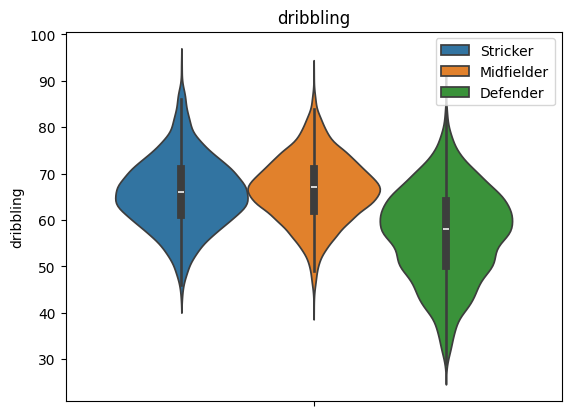

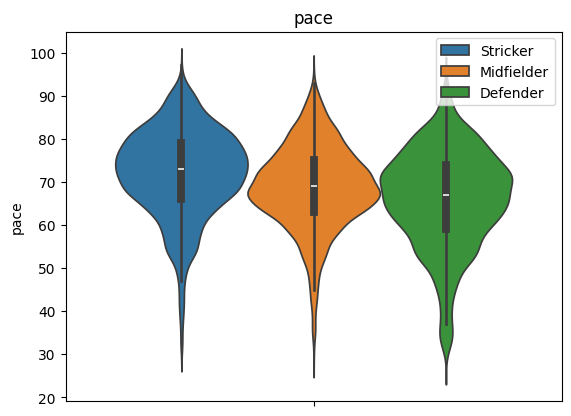

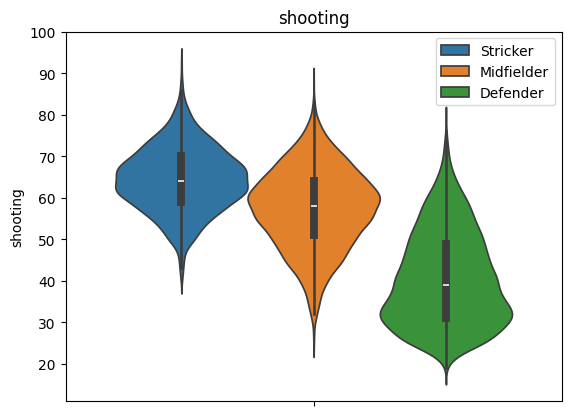

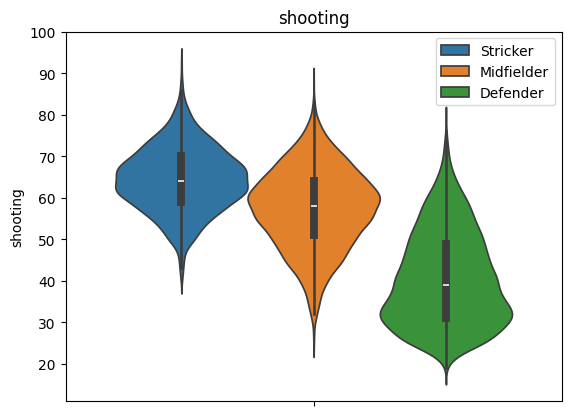

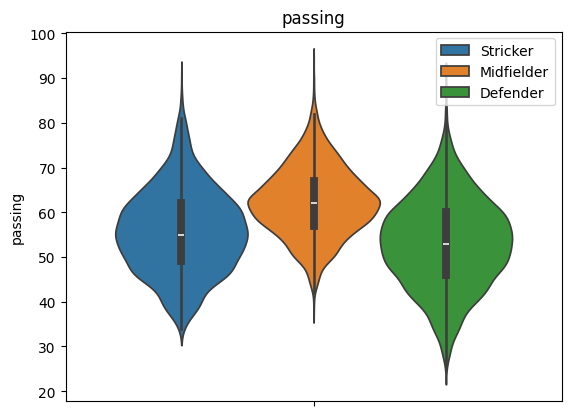

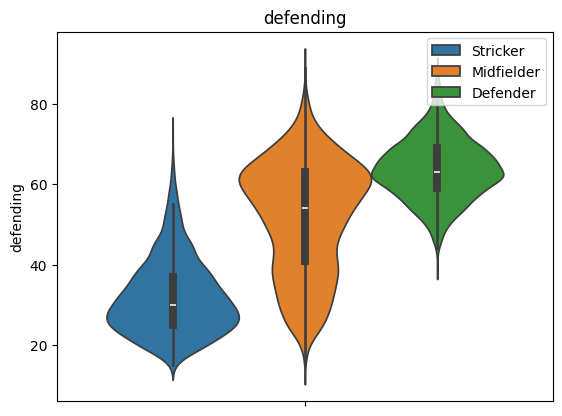

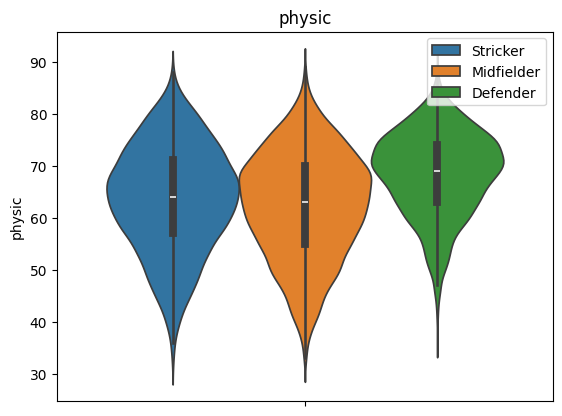

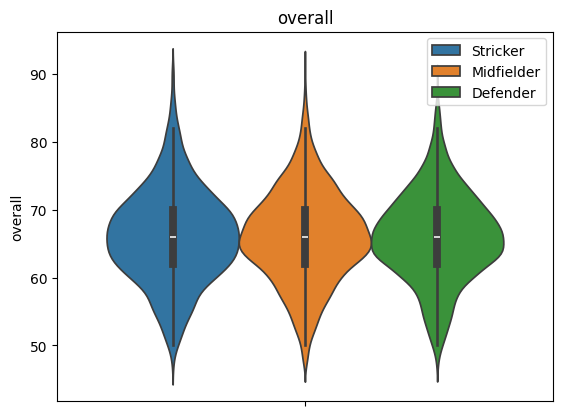

In [17]:
for col in stats:
    num_plots(df[df["player_positions"] != "GK"], col, "player_class")

### Graph description: game attributes by player class

The violin plots compare the distributions of six attributes (`dribbling`, `pace`, `shooting`, `passing`, `defending`, `physic`) across the three classes: Strikers, Midfielders, Defenders. Goalkeepers are excluded because these fields are empty for them.

- **dribbling, shooting, passing**: shifted upward for strikers and midfielders; defenders sit clearly lower, especially on `shooting`, where most defenders fall in the lower half of the scale.
- **defending**: the mirror image — defenders concentrate at the top of the scale, strikers stretch toward the bottom.
- **pace**: strikers have the narrowest, tallest distribution (few slow players); defenders are more spread out.
- **physic**: defenders have a higher median and a denser upper tail.

**Takeaway:** the attributes separate the classes cleanly along their on-pitch role — attacking stats rise from defenders to strikers, defensive stats do the opposite. This confirms the engineered `player_class` feature is meaningful.

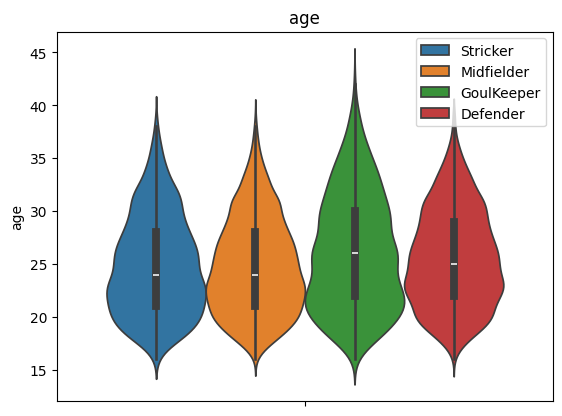

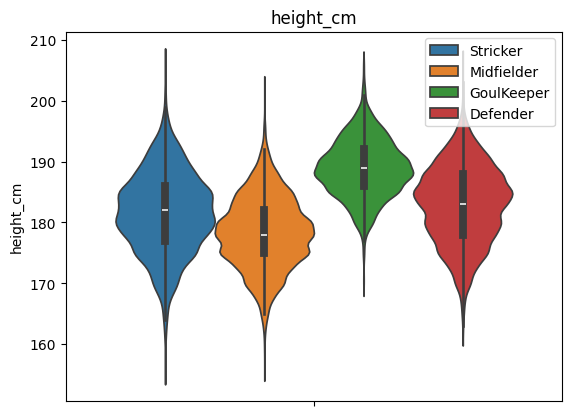

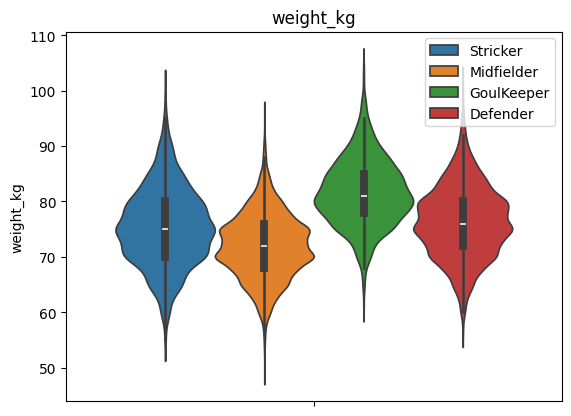

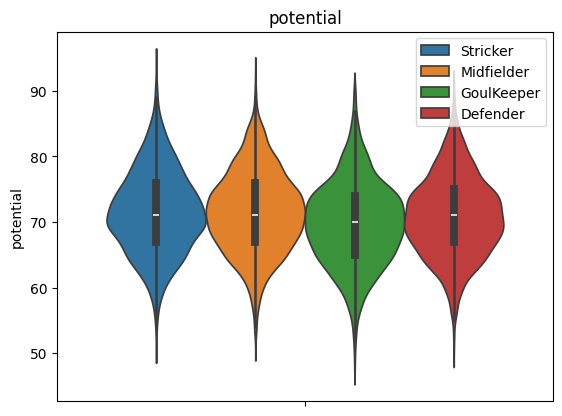

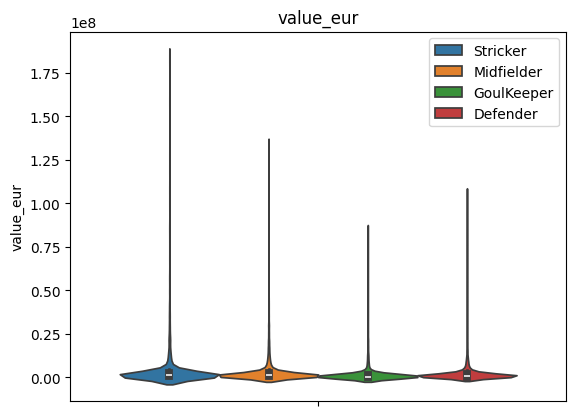

In [18]:
for col in player_info_num:
    num_plots(df, col, "player_class")

### Graph description: numeric features by player class

Comparing `age`, `height_cm`, `weight_kg`, `potential`, `value_eur` across classes.

- **height_cm, weight_kg**: defenders are clearly taller and heavier; midfielders are the smallest — consistent with positional demands (defenders contest aerial duels).
- **age**: distributions are similar across classes; no strong age difference between roles.
- **potential**: comparable across classes, most mass in the ~65–80 range.
- **value_eur**: strongly skewed for every class — most players are cheap, with a long tail of expensive ones.

**Takeaway:** size separates the classes, age and potential do not. The heavy skew of `value_eur` is the key observation for the value analysis that follows.

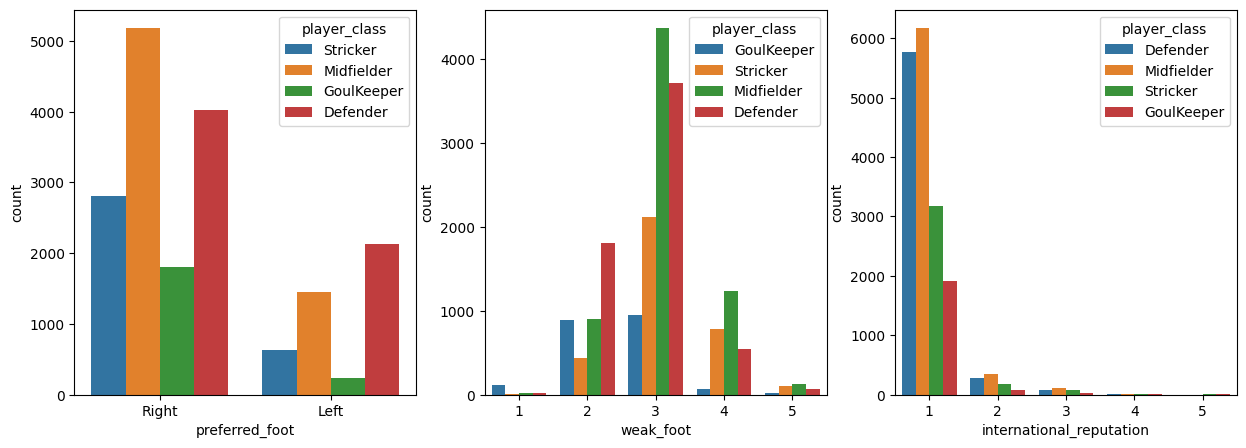

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
sns.countplot(df, x=player_info_cat[0], ax=ax[0], hue="player_class")
sns.countplot(df, x=player_info_cat[1], ax=ax[1], hue="player_class")
sns.countplot(df, x=player_info_cat[2], ax=ax[2], hue="player_class")
plt.show()

### Graph description: categorical features by player class

Three countplots show `preferred_foot`, `weak_foot` and `international_reputation`, split by class.

- **preferred_foot**: right-footers outnumber left-footers roughly 3:1 (~13 800 vs ~4 400), and the ratio holds across all three classes.
- **weak_foot**: most players have 2–3 stars; the distribution is roughly bell-shaped, with 1 and 5 rare.
- **international_reputation**: the overwhelming majority sit at reputation 1; counts fall off sharply for 2 and 3, and 4–5 are tiny. The feature is heavily imbalanced.

**Takeaway:** foot and weak-foot are distributed similarly across classes, while `international_reputation` is extremely imbalanced — important to remember for H3, where groups 4 and 5 are very small.

## EDA summary

- Cleaned dataset: **18 250 FIFA 24 players** (100 rows without `value_eur` dropped, ~0.5% of the subset).
- The 2045 missing `pace/shooting/...` values belong to **goalkeepers** — a structural feature, not an error; GKs are excluded from field-attribute comparisons.
- Game attributes separate the classes clearly along attacking vs defensive roles; size differs across classes, while age and potential barely do.
- **Key observation:** `value_eur` is strongly right-skewed, so `log10(value_eur)` is used throughout the hypothesis tests.
- `international_reputation` is heavily imbalanced (most players at level 1).

These observations frame the testing of H1–H5.

## Hypothesis testing — block 1

- **H1.** Value is non-linearly related to `overall` (close to exponential).
- **H2.** At equal `overall`, younger players are worth more.
- **H3.** Reputation forms a monotonic value ladder across all five levels.

### H1. Value is non-linearly related to `overall` (close to exponential)

Take `log10` of the player values to compress the heavy skew and bring the distribution closer to normal.

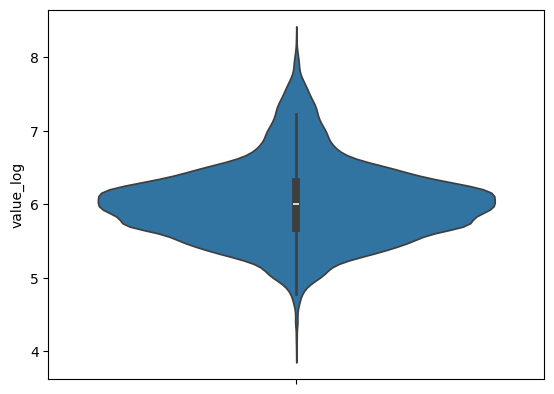

In [20]:
df["value_log"] = np.log10(df["value_eur"])
sns.violinplot(df, y = "value_log")
plt.show()

- **H0:** value depends *linearly* on `overall`.
- **H1:** value depends *non-linearly* on `overall` (close to exponential).

In [21]:
corr_raw = df["overall"].corr(df["value_eur"])
corr_log = df["overall"].corr(df["value_log"])

print("Pearson corr  overall vs value_eur (raw): ", round(corr_raw, 4))
print("Pearson corr  overall vs value_log (log): ", round(corr_log, 4))

Pearson corr  overall vs value_eur (raw):  0.5543
Pearson corr  overall vs value_log (log):  0.884


### Interpreting the correlations

- Pearson correlation between `overall` and **raw** `value_eur` ≈ **0.55** — positive but only moderate: the linear coefficient is held back by the heavy skew of value.
- Correlation between `overall` and **`value_log`** ≈ **0.88** — the relationship strengthens sharply after the log transform.

The jump from 0.55 to 0.88 when switching to the log scale means the value-vs-rating relationship is **not linear but close to exponential**: in log space it becomes almost a straight line.

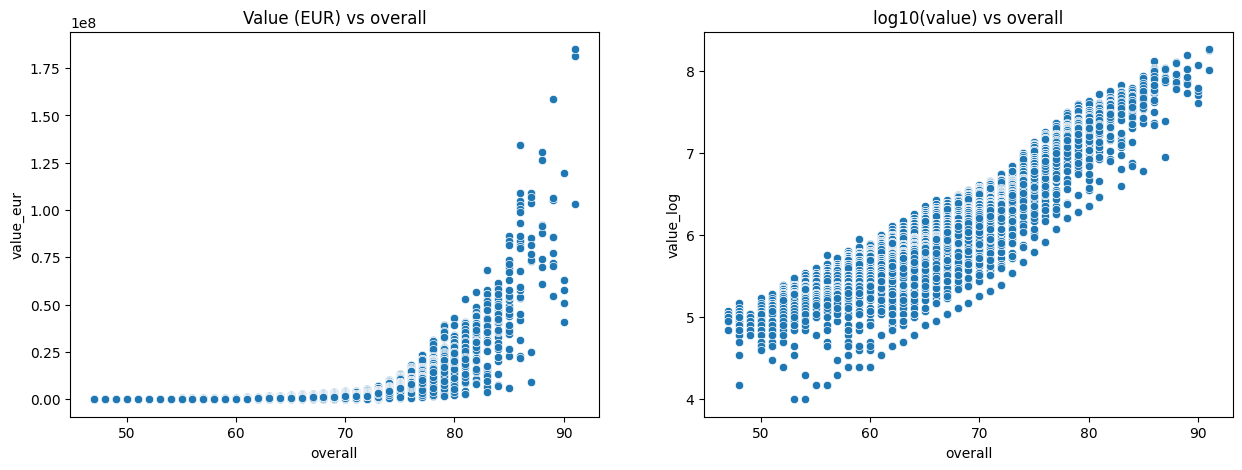

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
sns.scatterplot(df, x="overall", y="value_eur", ax=ax[0])
ax[0].set_title("Value (EUR) vs overall")
sns.scatterplot(df, x="overall", y="value_log", ax=ax[1])
ax[1].set_title("log10(value) vs overall")
plt.show()

### Conclusion — H1

**Supported.** On the left scatter plot (`value_eur` vs `overall`) the points form a sharply upward-curving cloud — value barely moves below ~75 overall and then explodes, i.e. the relationship is non-linear. On the right plot (`value_log` vs `overall`) the cloud straightens into an almost linear band.

This is confirmed numerically: Pearson correlation rises from **0.55** (raw) to **0.88** (log scale). The value gap between rating points *widens* as overall increases, so we **reject H0** in favour of a non-linear, near-exponential relationship.

### H2. At equal `overall`, younger players are worth more

- **H0:** at a fixed `overall`, age has no effect on value.
- **H1:** at a fixed `overall`, younger players have higher value than older ones.

Split players into two age groups by the median age (`is_adult`: 1 = older than median, 0 = young), then compare value **after removing the effect of `overall`**.

In [23]:
def age_cat(age):
    if age > df["age"].median():
        return 1
    else: return 0
df["is_adult"] = df["age"].apply(age_cat)
df['is_adult'].value_counts()

is_adult
0    10110
1     8140
Name: count, dtype: int64

In [24]:
adult_overall = df[df["is_adult"]== 1]
young_overall = df[df["is_adult"] == 0]

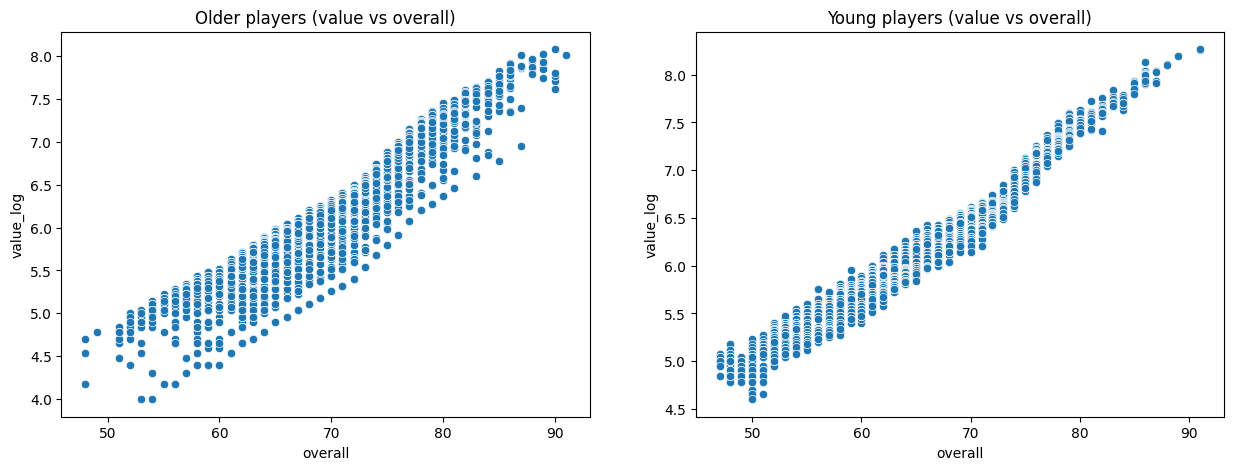

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
sns.scatterplot(adult_overall, x="overall", y="value_log", ax=ax[0])
ax[0].set_title("Older players (value vs overall)")
sns.scatterplot(young_overall, x="overall", y="value_log", ax=ax[1])
ax[1].set_title("Young players (value vs overall)")
plt.show()

In [26]:
import scipy.stats as stats

slope, intercept = np.polyfit(df["overall"], df["value_log"], 1)
df["value_resid"] = df["value_log"] - (slope * df["overall"] + intercept)

young_resid = df[df["is_adult"] == 0]["value_resid"]
adult_resid = df[df["is_adult"] == 1]["value_resid"]

t_stat, pvalue_h2 = stats.ttest_ind(
    young_resid, adult_resid, equal_var=False, alternative="greater"
)
print(f"Mean residual value (young)  : {young_resid.mean():+.3f}")
print(f"Mean residual value (older)  : {adult_resid.mean():+.3f}")
print(f"t = {t_stat:.1f}   p = {pvalue_h2:.2e}")
print("Reject H0 (young worth more at equal overall)" if pvalue_h2 < 0.05 else "Fail to reject H0")

Mean residual value (young)  : +0.146
Mean residual value (older)  : -0.182
t = 108.4   p = 0.00e+00
Reject H0 (young worth more at equal overall)


### Conclusion — H2

**Supported.** The hypothesis is that *at equal `overall`*, younger players are worth more.

**Graphs:** in the scatter pair, at any given `overall` the point cloud for young players sits **higher** than for older players.

**Correct test:** we first removed the linear effect of `overall` from `value_log` (a regression residual = the part of value *not* explained by rating), then compared this residual between the two age groups with a Welch t-test (one-sided, young > older):

- mean residual value, young: **+0.15**
- mean residual value, older: **−0.18**
- **t ≈ 108, p ≈ 0** → reject H0.

So, holding rating constant, younger players carry a systematically higher market value. A residual of +0.15 vs −0.18 in `log10` terms corresponds to young players being worth roughly **2x** more than equally-rated older players, which matches the per-rating-bin medians.

> Note: the earlier draft compared `overall` between groups (not value) with the wrong alternative, which returned p = 1.0 and did **not** test H2. The residual t-test above is the correct one-test approach and is sufficient — no further tests needed.

### H3. Higher `international_reputation` forms a monotonic value ladder

- **H0:** `value_eur` does not depend on `international_reputation`.
- **H1:** `value_eur` increases monotonically with `international_reputation`.

Split players into 5 groups by `international_reputation`.

In [27]:
groups = [df[df["international_reputation"] == r]["value_log"] for r in [1, 2, 3, 4, 5]]

rep_table = (df.groupby("international_reputation")["value_eur"]
             .median().astype(int).reset_index()
             .rename(columns={"value_eur": "median_value_eur"}))
print(rep_table.to_string(index=False))

 international_reputation  median_value_eur
                        1            925000
                        2           8500000
                        3          22000000
                        4          41750000
                        5          75750000


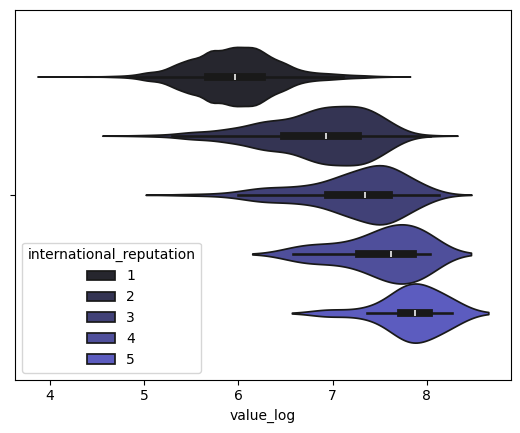

In [28]:
sns.violinplot(df, x = "value_log",hue="international_reputation",palette='dark:#4c4ccf')
plt.show()

Verify the difference between reputation groups with a test.

In [29]:
F, pvalue_h3 = stats.f_oneway(*groups)
print(f"ANOVA F = {F:.1f}")
print("p < 0.0001" if pvalue_h3 < 0.0001 else f"p = {pvalue_h3:.4f}")
print("Reject H0 (reputation groups differ in value)" if pvalue_h3 < 0.05 else "Fail to reject H0")

ANOVA F = 1326.7
p < 0.0001
Reject H0 (reputation groups differ in value)


### Conclusion — H3

**Supported.** On the violin plot of `value_log` split by `international_reputation`, the distributions shift steadily to the right as reputation rises — each level corresponds to a higher value, forming a clean monotonic ladder. The median-value table printed above makes this explicit: the median rises monotonically across all five levels (roughly ×80 from level 1 to level 5).

A one-way ANOVA gives **F ≈ 1327, p < 0.0001**, so the difference in means across groups is statistically significant — we **reject H0**. The monotonic ordering claimed by H3 holds across all five levels, not just the extremes.

### H4. Left-footed field players are more technical (`dribbling`, `skill_moves`)

- **H0:** preferred foot has no relation to technical attributes.
- **H1:** left-footers have higher `dribbling` / `skill_moves` than right-footers.

We compare **field players only** (goalkeepers excluded, since their attributes work differently). We also check whether any difference is large or just small-but-real.

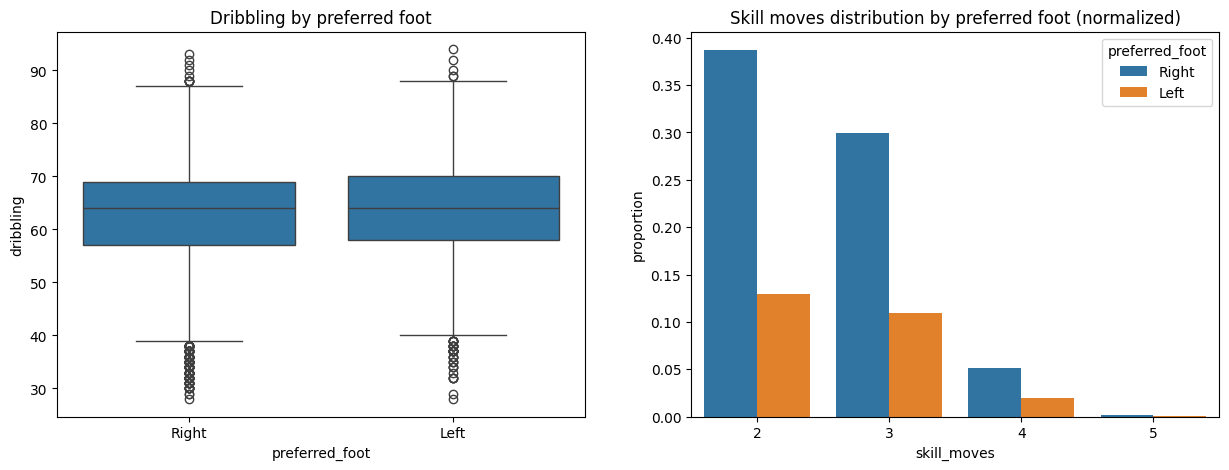

Medians:
                dribbling  skill_moves
preferred_foot                        
Left                 64.0          3.0
Right                64.0          2.0

Means:
                dribbling  skill_moves
preferred_foot                        
Left               63.438        2.582
Right              62.607        2.552


In [30]:
field = df[df["player_positions"].str.split(",").str[0].str.strip() != "GK"]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
sns.boxplot(field, x="preferred_foot", y="dribbling", ax=ax[0])
ax[0].set_title("Dribbling by preferred foot")
sns.countplot(field, x="skill_moves", hue="preferred_foot", stat="proportion", ax=ax[1])
ax[1].set_title("Skill moves distribution by preferred foot (normalized)")
plt.show()

print("Medians:")
print(field.groupby("preferred_foot")[["dribbling", "skill_moves"]].median())
print("\nMeans:")
print(field.groupby("preferred_foot")[["dribbling", "skill_moves"]].mean().round(3))

### Conclusion — H4

**Partially supported — the effect is small but real.**

- **dribbling**: the box plots are almost identical, medians equal at **64** (means 63.4 left vs 62.6 right). Practically no difference.
- **skill_moves**: a small but consistent shift — left-footers have a higher median (**3 vs 2**) and a slightly larger share of 3–4 star players (mean 2.58 vs 2.55).

So the "left-footers are more technical" idea holds **only weakly**, and only for `skill_moves`, not `dribbling`. This is exactly the *"there is a change, but it's quite small"* outcome the brief allows — we don't over-claim. No statistical test is needed here; the graphs and medians already show the effect is marginal. We do **not** reject H0 in any practically meaningful sense.

### H5. Left-footers look more valuable — but does the gap survive controlling for `overall`?

This is the "complex" hypothesis: a base comparison (left vs right value) **with a condition layered on top** (at equal `overall`).

- **H0:** the raw value gap between left- and right-footers is explained by `overall` — it disappears once rating is held constant.
- **H1:** left-footers are worth more even at equal `overall`.

We first look at the raw gap, then split by overall band to see whether it persists.

Raw median value by foot:
preferred_foot
Left     1100000.0
Right     975000.0
Name: value_eur, dtype: float64

Mean overall by foot: {'Left': 66.32, 'Right': 65.63}

Median value within overall bands:
overall_band       Left      Right
       60-69   900000.0   900000.0
       70-79  3100000.0  3100000.0
       80-99 30500000.0 30000000.0


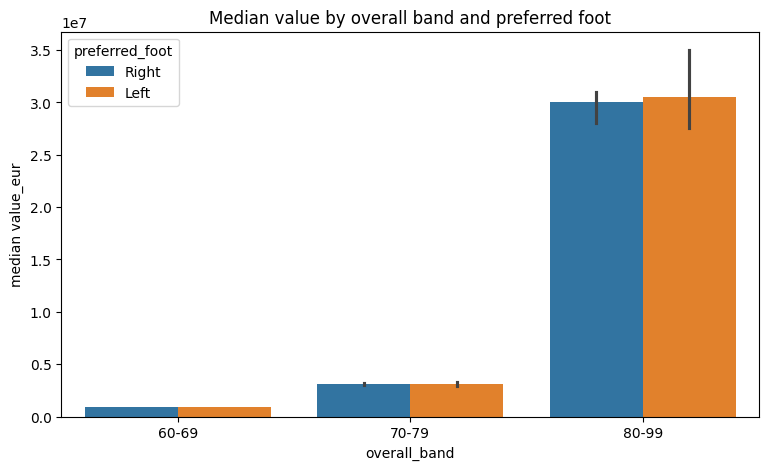

In [31]:
print("Raw median value by foot:")
print(df.groupby("preferred_foot")["value_eur"].median())
print("\nMean overall by foot:", df.groupby("preferred_foot")["overall"].mean().round(2).to_dict())

bands = [(60, 69), (70, 79), (80, 99)]
rows = []
for lo, hi in bands:
    s = df[(df["overall"] >= lo) & (df["overall"] <= hi)]
    rows.append({
        "overall_band": f"{lo}-{hi}",
        "Left": s[s["preferred_foot"] == "Left"]["value_eur"].median(),
        "Right": s[s["preferred_foot"] == "Right"]["value_eur"].median(),
    })
controlled = pd.DataFrame(rows)
print("\nMedian value within overall bands:")
print(controlled.to_string(index=False))

df["overall_band"] = pd.cut(df["overall"], bins=[59, 69, 79, 99],
                            labels=["60-69", "70-79", "80-99"])
plt.figure(figsize=(9, 5))
sns.barplot(df, x="overall_band", y="value_eur", hue="preferred_foot", estimator="median")
plt.title("Median value by overall band and preferred foot")
plt.ylabel("median value_eur")
plt.show()

### Conclusion — H5

**H0 supported, H1 rejected — the raw value gap is a confound.**

- **Raw:** left-footers do look more valuable — median **1.10M** vs **0.98M** for right-footers.
- **But** left-footers also have a slightly higher mean `overall` (**66.3 vs 65.6**) and a different position mix (more defenders/wide attackers).
- **Controlled (within overall bands):** the per-band table printed above shows the gap essentially vanishes — at equal rating, left- and right-footers are valued almost identically (e.g. 900k vs 900k in the 60–69 band, 30.5M vs 30.0M in the 80–99 band).

So the headline "left-footers are pricier" is **real but misleading**: it is driven by their marginally higher ratings, not by foot itself. This is the kind of nuanced result the brief encourages — a visible raw effect that dissolves once you control for the right variable.

## Final summary

| Hypothesis | Result | Evidence |
|---|---|---|
| **H1** value non-linear in `overall` | **Supported** | scatter curve + corr 0.55 → 0.88 (log) |
| **H2** young worth more at equal `overall` | **Supported** | residual Welch t-test, t≈108, p≈0 |
| **H3** monotonic value ladder by reputation | **Supported** | violin + ANOVA p<0.0001, medians ×80 |
| **H4** left-footers more technical | **Weak / small effect** | medians: dribbling equal, skill_moves 3 vs 2 |
| **H5** left-footers worth more | **Rejected (confound)** | raw gap vanishes within overall bands |

**Overall.** A player's market value is driven mainly by `overall` (non-linearly), with age and reputation adding real, separable information on top. Preferred foot, by contrast, has little genuine effect — its apparent value advantage disappears once rating is controlled, and its link to technical skill is marginal. Two statistical tests were used in total (a residual t-test for H2 and an ANOVA for H3); the remaining hypotheses are demonstrated with figures and descriptive statistics, as the patterns are clear without further testing.